In [49]:
## Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Plotting defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

## Load the data

In [50]:
data=pd.read_csv("starbucks_customer_ordering_patterns.csv")
data.head()

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3


In [51]:
print(f"Dataset shape: {data.shape[0]:,} rows x {data.shape[1]} columns")
print(f"Memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print("Column types:")
print(data.dtypes.to_string())

Dataset shape: 100,000 rows x 20 columns
Memory usage: 68.8 MB

Column types:
customer_id                  str
order_id                     str
order_date                   str
order_time                   str
day_of_week                  str
order_channel                str
store_id                     str
store_location_type          str
region                       str
customer_age_group           str
customer_gender              str
is_rewards_member           bool
cart_size                  int64
num_customizations         int64
total_spend              float64
fulfillment_time_min     float64
drink_category               str
has_food_item               bool
order_ahead                 bool
customer_satisfaction      int64


In [52]:
data.describe().round(2)

,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.00,100000.00,100000.00,100000.00,100000.00
mean,3.74,1.81,14.87,4.55,3.69
std,1.70,1.46,5.51,1.55,1.18
min,1.00,0.00,3.51,1.00,1.00
25%,3.00,1.00,10.84,3.40,3.00
50%,4.00,2.00,14.17,4.40,4.00
75%,5.00,3.00,18.18,5.50,5.00
max,10.00,8.00,40.31,11.20,5.00



At a glance, the numbers look reasonable. There are 100K orders from roughly 15K customers, so repeat ordering is definitely present. A typical order has about 3.7 items, close to 2 customizations, costs about $14.87, and takes around 4.5 minutes to fulfill. Average satisfaction is 3.69 out of 5, which feels okay but not especially high.

The numeric columns also look fairly stable. Means and medians are not too far apart for the main variables, so there is no obvious distortion from extreme values. Even the maximum values still look believable for this kind of dataset. So nothing looks off yet, but this is only the starting point.


In [53]:
data.isnull().sum()

customer_id              0
order_id                 0
order_date               0
order_time               0
day_of_week              0
order_channel            0
store_id                 0
store_location_type      0
region                   0
customer_age_group       0
customer_gender          0
is_rewards_member        0
cart_size                0
num_customizations       0
total_spend              0
fulfillment_time_min     0
drink_category           0
has_food_item            0
order_ahead              0
customer_satisfaction    0
dtype: int64

## Basic structure checks

Before moving further, I want to confirm a few basics:
- Is each row one order or one customer snapshot?
- What time range does the data cover?
- Are there enough repeat customers to make segmentation worthwhile?

In [54]:
# Unique counts for key identifiers
print("=== Identity Check ===")
print(f"Unique customers:  {data['customer_id'].nunique():,}")
print(f"Unique orders:     {data['order_id'].nunique():,}")
print(f"Unique stores:     {data['store_id'].nunique():,}")
print()

# Date range
data["order_date"] = pd.to_datetime(data["order_date"])
print(f"Date range: {data['order_date'].min().date()}  --  {data['order_date'].max().date()}")
print(f"Span:       {(data['order_date'].max() - data['order_date'].min()).days} days")
print()

# Duplicates
dup_orders = data["order_id"].duplicated().sum()
print(f"Duplicate order_id rows: {dup_orders}")
print()

# Orders per customer
orders_per_cust = data.groupby("customer_id").size()
print(f"Orders per customer - mean: {orders_per_cust.mean():.1f}, "
      f"median: {orders_per_cust.median():.0f}, "
      f"min: {orders_per_cust.min()}, max: {orders_per_cust.max()}")

=== Identity Check ===
Unique customers:  14,988
Unique orders:     100,000
Unique stores:     500

Date range: 2024-01-01  →  2025-12-30
Span:       729 days

Duplicate order_id rows: 0

Orders per customer — mean: 6.7, median: 6, min: 1, max: 18


This confirms each row is a single order. Since the same customers appear multiple times,
it makes more sense to do segmentation at the customer level after aggregation.

## Quick data quality check

In [ ]:
# Day of Week
print("=== day_of_week ===")
print(data["day_of_week"].value_counts().to_string())
print(f"  -- {data['day_of_week'].nunique()} unique values")

In [ ]:
# Order Channel
print("=== order_channel ===")
print(data["order_channel"].value_counts().to_string())
print(f"  -- {data['order_channel'].nunique()} unique values")

In [ ]:
# Store Location Type
print("=== store_location_type ===")
print(data["store_location_type"].value_counts().to_string())
print(f"  -- {data['store_location_type'].nunique()} unique values")

In [ ]:
# Region
print("=== region ===")
print(data["region"].value_counts().to_string())
print(f"  -- {data['region'].nunique()} unique values")

In [ ]:
# Customer Age Group
print("=== customer_age_group ===")
print(data["customer_age_group"].value_counts().to_string())
print(f"  -- {data['customer_age_group'].nunique()} unique values")

In [ ]:
# Customer Gender
print("=== customer_gender ===")
print(data["customer_gender"].value_counts().to_string())
print(f"  -- {data['customer_gender'].nunique()} unique values")

In [ ]:
# Drink Category
print("=== drink_category ===")
print(data["drink_category"].value_counts().to_string())
print(f"  -- {data['drink_category'].nunique()} unique values")

In [56]:
# Binary column validation
binary_cols = ["is_rewards_member", "has_food_item", "order_ahead"]
print("=== Binary Column Shares ===")
for col in binary_cols:
    pct = data[col].mean() * 100
    print(f"  {col:25s}  True: {pct:.1f}%   False: {100-pct:.1f}%")

=== Binary Column Shares ===
  is_rewards_member          True: 47.7%   False: 52.3%
  has_food_item              True: 31.6%   False: 68.4%
  order_ahead                True: 29.8%   False: 70.2%


The categorical fields look clean and the binary columns are behaving as expected.
At this stage, I do not see any obvious cleanup issues that would block the analysis.

## Exploring the data step by step

Instead of plotting everything, I am using each chart only when it helps answer a specific question.

### Question 1: When do people order most?

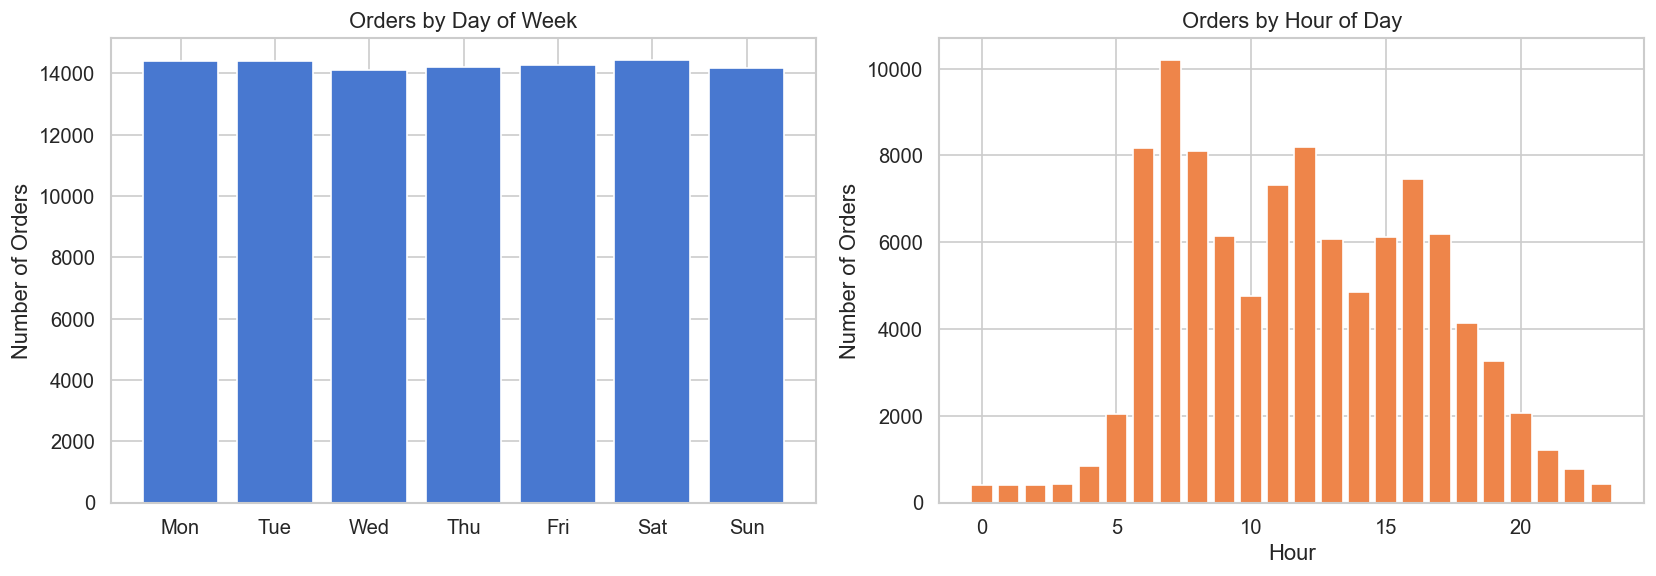

In [57]:
data["order_hour"] = data["order_time"].str.split(":").str[0].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
day_counts = data["day_of_week"].value_counts().reindex(day_order)
axes[0].bar(day_counts.index, day_counts.values, color=sns.color_palette("muted")[0])
axes[0].set_title("Orders by Day of Week")
axes[0].set_ylabel("Number of Orders")

# Hour of day
hour_counts = data["order_hour"].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color=sns.color_palette("muted")[1])
axes[1].set_title("Orders by Hour of Day")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

There is no major difference across days, but the hourly pattern is more useful.
The morning period clearly stands out, so time-of-day looks like something worth carrying into customer features.

### Question 2: Which channels matter most?

                  orders  share_%  avg_spend
order_channel                               
Mobile App         42521     42.5      18.08
Drive-Thru         27996     28.0      12.48
In-Store Cashier   22063     22.1      12.51
Kiosk               7420      7.4      12.49


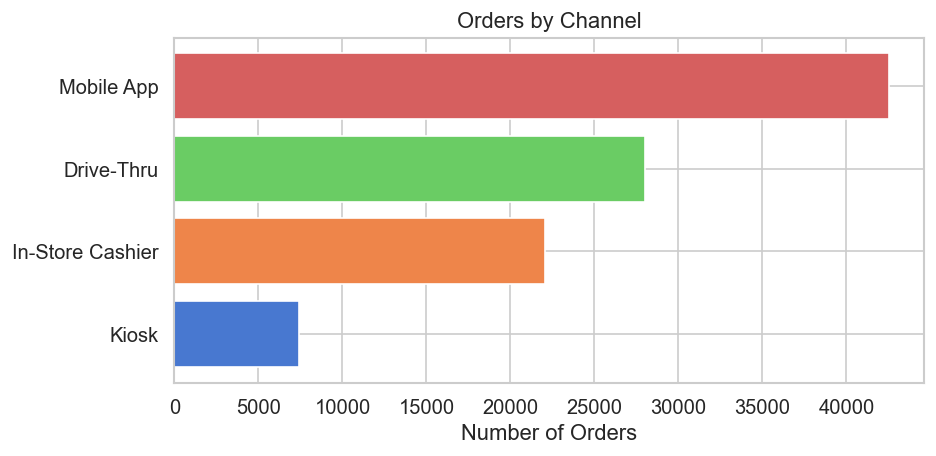

In [58]:
channel_counts = data["order_channel"].value_counts()
channel_spend = data.groupby("order_channel")["total_spend"].mean().round(2)

summary = pd.DataFrame({
    "orders": channel_counts,
    "share_%": (channel_counts / len(data) * 100).round(1),
    "avg_spend": channel_spend
}).sort_values("orders", ascending=False)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(summary.index[::-1], summary["orders"][::-1],
        color=sns.color_palette("muted", n_colors=len(summary)))
ax.set_xlabel("Number of Orders")
ax.set_title("Orders by Channel")
plt.tight_layout()
plt.show()

The channel mix is not extremely one-sided, but Mobile App and Drive-Thru stand out enough
to treat convenience preference as a meaningful customer trait.

### Question 3: What are people ordering?

In [59]:
drink_counts = data["drink_category"].value_counts()
drink_spend = data.groupby("drink_category")["total_spend"].mean().round(2)

drink_summary = pd.DataFrame({
    "orders": drink_counts,
    "share_%": (drink_counts / len(data) * 100).round(1),
    "avg_spend": drink_spend
}).sort_values("orders", ascending=False)
print(drink_summary.to_string())

                orders  share_%  avg_spend
drink_category                            
Refresher        16808     16.8      14.85
Tea              16723     16.7      14.91
Espresso         16711     16.7      14.82
Frappuccino      16670     16.7      14.88
Other            16547     16.5      14.87
Brewed Coffee    16541     16.5      14.87


Drink choice varies enough to be useful later. When I move to customer-level features,
I can keep each customer's most common drink category as a preference signal.

### Question 4: Do rewards members behave differently?

In [60]:
rewards_comparison = data.groupby("is_rewards_member").agg(
    avg_spend=("total_spend", "mean"),
    avg_cart_size=("cart_size", "mean"),
    avg_customizations=("num_customizations", "mean"),
    order_ahead_rate=("order_ahead", "mean"),
    has_food_rate=("has_food_item", "mean"),
    avg_satisfaction=("customer_satisfaction", "mean"),
    order_count=("order_id", "count")
).round(3)
print(rewards_comparison.to_string())

                   avg_spend  avg_cart_size  avg_customizations  order_ahead_rate  has_food_rate  avg_satisfaction  order_count
is_rewards_member                                                                                                              
False                 14.089          3.627               1.642             0.203          0.299             3.650        52283
True                  15.719          3.867               1.995             0.402          0.334             3.729        47717



=== Channel Mix by Rewards Status (%) ===
order_channel      Drive-Thru  In-Store Cashier  Kiosk  Mobile App
is_rewards_member                                                 
False                    34.7              27.3    9.3        28.8
True                     20.7              16.4    5.4        57.6


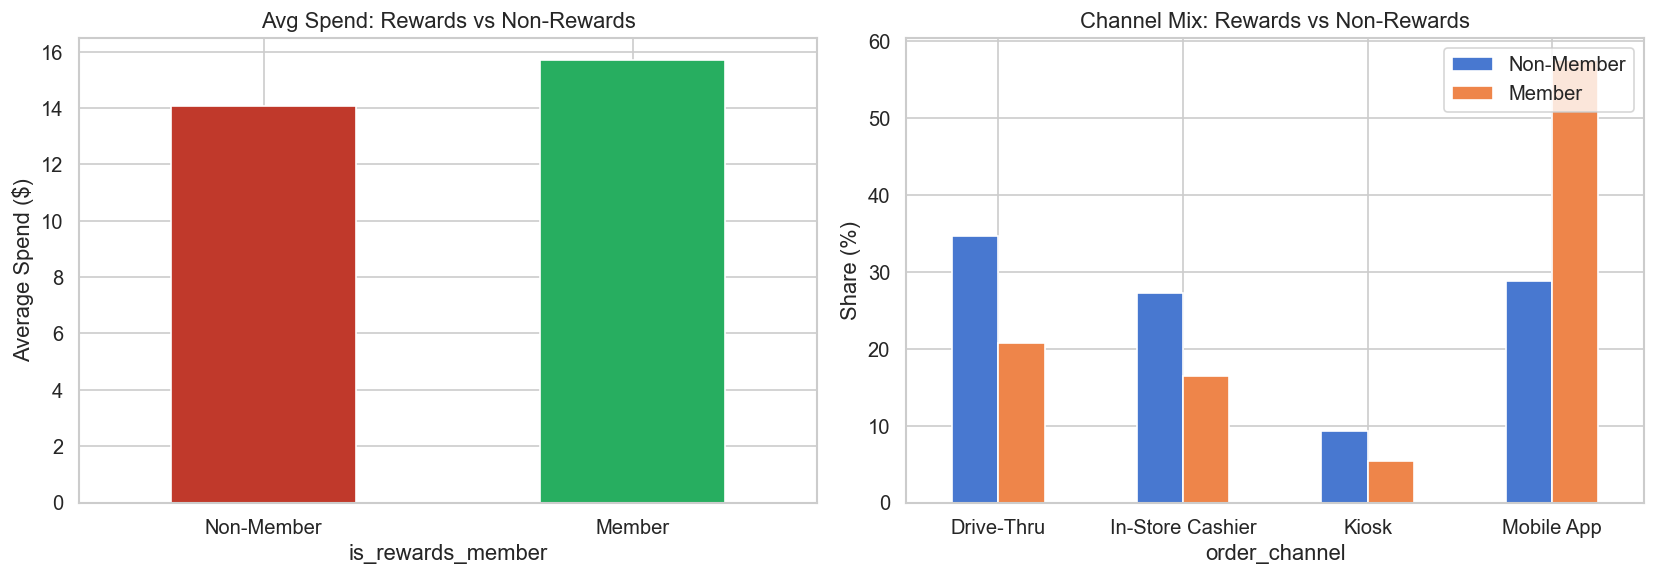

In [61]:
# Cross-tab: rewards × channel
rewards_channel = pd.crosstab(data["is_rewards_member"], data["order_channel"],
                               normalize="index").round(3) * 100
print("\n=== Channel Mix by Rewards Status (%) ===")
print(rewards_channel.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rewards_comparison["avg_spend"].plot.bar(ax=axes[0], color=["#c0392b", "#27ae60"],
                                         rot=0, edgecolor="white")
axes[0].set_title("Avg Spend: Rewards vs Non-Rewards")
axes[0].set_ylabel("Average Spend ($)")
axes[0].set_xticklabels(["Non-Member", "Member"])

rewards_channel.T.plot.bar(ax=axes[1], rot=0, edgecolor="white")
axes[1].set_title("Channel Mix: Rewards vs Non-Rewards")
axes[1].set_ylabel("Share (%)")
axes[1].legend(["Non-Member", "Member"], loc="upper right")

plt.tight_layout()
plt.show()

There are visible differences between members and non-members, especially in behavior and channel usage.
That makes rewards status worth keeping for customer profiling.

### Question 5: Does satisfaction change with speed or channel?

In [62]:
data["fulfillment_bucket"] = pd.cut(data["fulfillment_time_min"],
                                     bins=[0, 3, 5, 7, 12],
                                     labels=["<3 min", "3-5 min", "5-7 min", "7+ min"])

sat_by_fulfillment = data.groupby("fulfillment_bucket", observed=True).agg(
    avg_satisfaction=("customer_satisfaction", "mean"),
    order_count=("order_id", "count")
).round(2)
print("=== Satisfaction by Fulfillment Time ===")
print(sat_by_fulfillment.to_string())

sat_by_channel = data.groupby("order_channel").agg(
    avg_satisfaction=("customer_satisfaction", "mean"),
    avg_fulfillment=("fulfillment_time_min", "mean")
).round(2).sort_values("avg_satisfaction", ascending=False)
print("\n=== Satisfaction by Channel ===")
print(sat_by_channel.to_string())

=== Satisfaction by Fulfillment Time ===
                    avg_satisfaction  order_count
fulfillment_bucket                               
<3 min                          3.72        16948
3-5 min                         3.73        47883
5-7 min                         3.64        28667
7+ min                          3.50         6502

=== Satisfaction by Channel ===
                  avg_satisfaction  avg_fulfillment
order_channel                                      
Mobile App                    3.86             4.51
In-Store Cashier              3.70             3.20
Kiosk                         3.60             4.01
Drive-Thru                    3.44             5.80


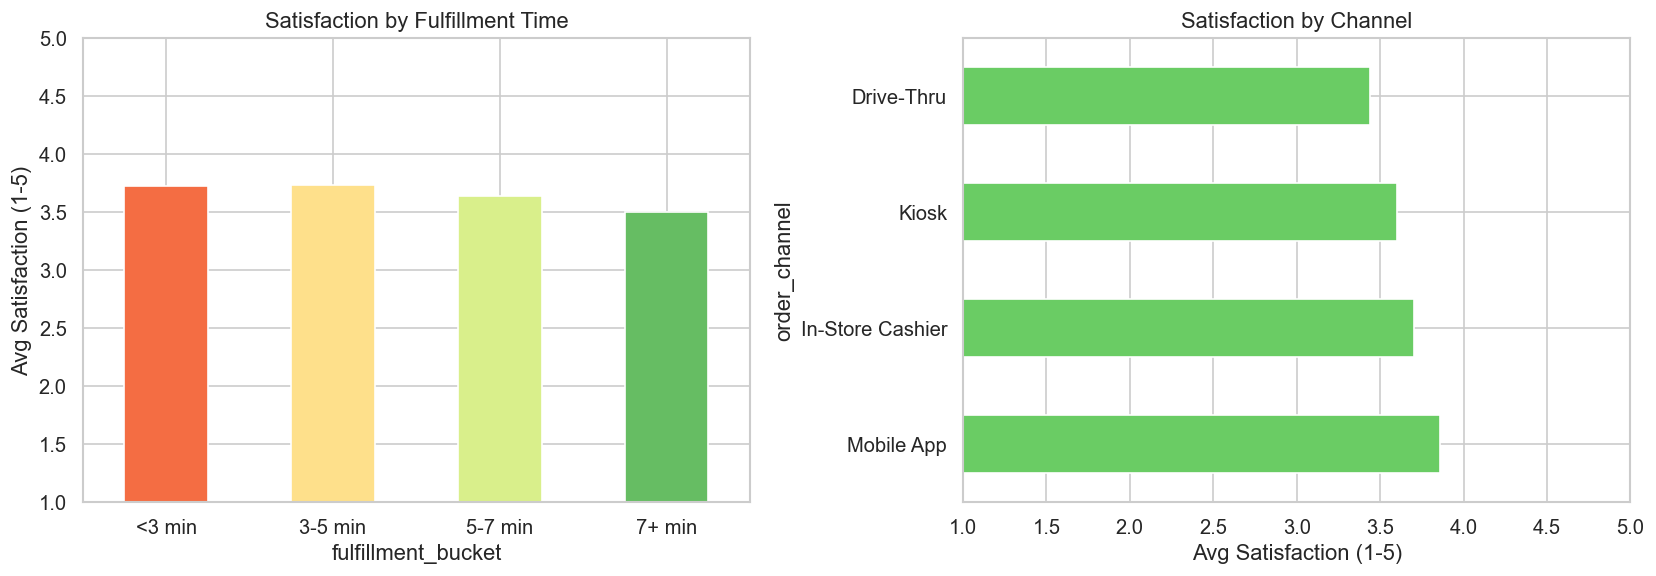

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sat_by_fulfillment["avg_satisfaction"].plot.bar(ax=axes[0],
    color=sns.color_palette("RdYlGn", 4), rot=0, edgecolor="white")
axes[0].set_title("Satisfaction by Fulfillment Time")
axes[0].set_ylabel("Avg Satisfaction (1-5)")
axes[0].set_ylim(1, 5)

sat_by_channel["avg_satisfaction"].plot.barh(ax=axes[1],
    color=sns.color_palette("muted")[2], edgecolor="white")
axes[1].set_title("Satisfaction by Channel")
axes[1].set_xlabel("Avg Satisfaction (1-5)")
axes[1].set_xlim(1, 5)

plt.tight_layout()
plt.show()

The effect is there, but it is not huge. Even so, average customer satisfaction still looks useful,
especially if I want to identify lower-satisfaction segments later.

---
## Build customer-level features

Since the raw data is at the order level, I need to aggregate it to the customer level before clustering.
This is where order behavior turns into customer features.

In [64]:
# Parse dates for recency/tenure calculation
max_date = data["order_date"].max()

# Time-of-day buckets
data["time_period"] = pd.cut(data["order_hour"],
                              bins=[-1, 11, 16, 23],
                              labels=["morning", "afternoon", "evening"])

data["is_weekend"] = data["day_of_week"].isin(["Sat", "Sun"]).astype(int)

In [65]:
# Core aggregation
customer_agg = data.groupby("customer_id").agg(
    # Value & volume
    total_orders=("order_id", "count"),
    avg_cart_size=("cart_size", "mean"),
    avg_num_customizations=("num_customizations", "mean"),
    avg_total_spend=("total_spend", "mean"),
    total_revenue=("total_spend", "sum"),
    # Operational
    avg_fulfillment_time=("fulfillment_time_min", "mean"),
    avg_customer_satisfaction=("customer_satisfaction", "mean"),
    # Dates
    first_order_date=("order_date", "min"),
    last_order_date=("order_date", "max"),
    # Preferences
    food_order_rate=("has_food_item", "mean"),
    order_ahead_rate=("order_ahead", "mean"),
    is_rewards_member=("is_rewards_member", lambda x: x.mode().iloc[0]),
    # Time behavior
    weekend_order_rate=("is_weekend", "mean"),
).reset_index()

# Recency & tenure
customer_agg["customer_tenure_days"] = (customer_agg["last_order_date"] - customer_agg["first_order_date"]).dt.days
customer_agg["recency_days"] = (max_date - customer_agg["last_order_date"]).dt.days

# Order frequency: orders per 30-day period of tenure
customer_agg["order_frequency"] = np.where(
    customer_agg["customer_tenure_days"] > 0,
    customer_agg["total_orders"] / (customer_agg["customer_tenure_days"] / 30),
    customer_agg["total_orders"]
)

In [66]:
# Channel mix features
channel_dummies = pd.get_dummies(data["order_channel"])
channel_rates = data.assign(**channel_dummies).groupby("customer_id")[channel_dummies.columns.tolist()].mean()
channel_rates.columns = [c.lower().replace(" ", "_").replace("-", "_") + "_rate" for c in channel_rates.columns]
customer_agg = customer_agg.merge(channel_rates, on="customer_id", how="left")

# Time-of-day features
time_dummies = pd.get_dummies(data["time_period"])
time_rates = data.assign(**time_dummies).groupby("customer_id")[time_dummies.columns.tolist()].mean()
time_rates.columns = [c + "_rate" for c in time_rates.columns]
customer_agg = customer_agg.merge(time_rates, on="customer_id", how="left")

# Favorite drink category
fav_drink = data.groupby("customer_id")["drink_category"].agg(
    lambda x: x.mode().iloc[0]).rename("favorite_drink_category")
customer_agg = customer_agg.merge(fav_drink, on="customer_id", how="left")

# Drop date columns (no longer needed for clustering)
customer_agg = customer_agg.drop(columns=["first_order_date", "last_order_date"])

print(f"Customer-level dataset: {customer_agg.shape[0]:,} customers × {customer_agg.shape[1]} features")
customer_agg.head()

Customer-level dataset: 14,988 customers × 23 features


,customer_id,total_orders,avg_cart_size,avg_num_customizations,avg_total_spend,total_revenue,avg_fulfillment_time,avg_customer_satisfaction,food_order_rate,order_ahead_rate,...,recency_days,order_frequency,drive_thru_rate,in_store_cashier_rate,kiosk_rate,mobile_app_rate,morning_rate,afternoon_rate,evening_rate,favorite_drink_category
0,CUST_00001,12,3.666667,2.500000,14.550000,174.60,5.133333,3.250000,0.250000,0.250000,...,40,0.574163,0.500000,0.166667,0.083333,0.250000,0.416667,0.583333,0.000000,Brewed Coffee
1,CUST_00002,13,4.076923,2.076923,15.936923,207.18,4.461538,4.076923,0.461538,0.384615,...,61,0.657673,0.307692,0.153846,0.000000,0.538462,0.230769,0.307692,0.461538,Refresher
2,CUST_00003,5,4.200000,1.200000,15.942000,79.71,4.940000,3.400000,0.200000,0.400000,...,83,0.410959,0.200000,0.200000,0.000000,0.600000,0.200000,0.600000,0.200000,Espresso
3,CUST_00004,7,3.571429,2.000000,13.692857,95.85,4.742857,4.142857,0.428571,0.142857,...,145,0.383212,0.571429,0.142857,0.000000,0.285714,0.571429,0.285714,0.142857,Other
4,CUST_00005,3,4.666667,1.333333,15.816667,47.45,4.733333,3.666667,0.333333,0.000000,...,79,0.620690,0.666667,0.000000,0.333333,0.000000,1.000000,0.000000,0.000000,Espresso


## Check the engineered features

Before clustering, I want to check a few things:
- Do features have enough variation to actually separate customers?
- Are any features just duplicates of each other?
- Anything skewed enough to need a log transform?

In [67]:
# Customer-level describe
numeric_features = customer_agg.select_dtypes(include=[np.number]).columns.tolist()
customer_agg[numeric_features].describe().round(2)

,total_orders,avg_cart_size,avg_num_customizations,avg_total_spend,total_revenue,avg_fulfillment_time,avg_customer_satisfaction,food_order_rate,order_ahead_rate,weekend_order_rate,customer_tenure_days,recency_days,order_frequency,drive_thru_rate,in_store_cashier_rate,kiosk_rate,mobile_app_rate,morning_rate,afternoon_rate,evening_rate
count,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00
mean,6.67,3.74,1.82,14.87,99.19,4.55,3.69,0.31,0.30,0.29,512.95,107.59,0.43,0.28,0.22,0.07,0.43,0.49,0.33,0.18
std,2.56,0.74,0.65,2.47,40.97,0.66,0.51,0.20,0.22,0.19,148.26,105.03,0.44,0.19,0.19,0.11,0.25,0.22,0.20,0.17
min,1.00,1.00,0.00,3.83,3.83,1.50,1.00,0.00,0.00,0.00,0.00,0.00,0.09,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.00,3.25,1.38,13.23,69.79,4.12,3.38,0.17,0.14,0.17,437.00,31.00,0.30,0.14,0.00,0.00,0.25,0.33,0.20,0.00
50%,6.00,3.71,1.78,14.76,95.60,4.53,3.71,0.31,0.29,0.27,547.00,75.00,0.39,0.25,0.20,0.00,0.43,0.50,0.33,0.17
75%,8.00,4.20,2.20,16.38,124.86,4.96,4.00,0.43,0.43,0.40,624.00,152.00,0.49,0.40,0.33,0.14,0.60,0.62,0.45,0.29
max,18.00,9.00,8.00,29.18,301.68,10.10,5.00,1.00,1.00,1.00,728.00,727.00,30.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [68]:
# Check skewness
skew_report = customer_agg[numeric_features].skew().sort_values(ascending=False).round(2)
print("=== Feature Skewness ===")
print(skew_report.to_string())
print()
highly_skewed = skew_report[skew_report.abs() > 1]
if len(highly_skewed) > 0:
    print(f"Highly skewed features (|skew| > 1): {list(highly_skewed.index)}")
else:
    print("No highly skewed features (ok)")

=== Feature Skewness ===
order_frequency              44.49
kiosk_rate                    1.93
recency_days                  1.76
evening_rate                  0.98
in_store_cashier_rate         0.93
avg_num_customizations        0.58
weekend_order_rate            0.56
drive_thru_rate               0.56
total_revenue                 0.50
order_ahead_rate              0.50
food_order_rate               0.44
total_orders                  0.41
avg_cart_size                 0.41
afternoon_rate                0.41
avg_total_spend               0.37
avg_fulfillment_time          0.23
mobile_app_rate               0.11
morning_rate                  0.03
avg_customer_satisfaction    -0.35
customer_tenure_days         -1.12

Highly skewed features (|skew| > 1): ['order_frequency', 'kiosk_rate', 'recency_days', 'customer_tenure_days']


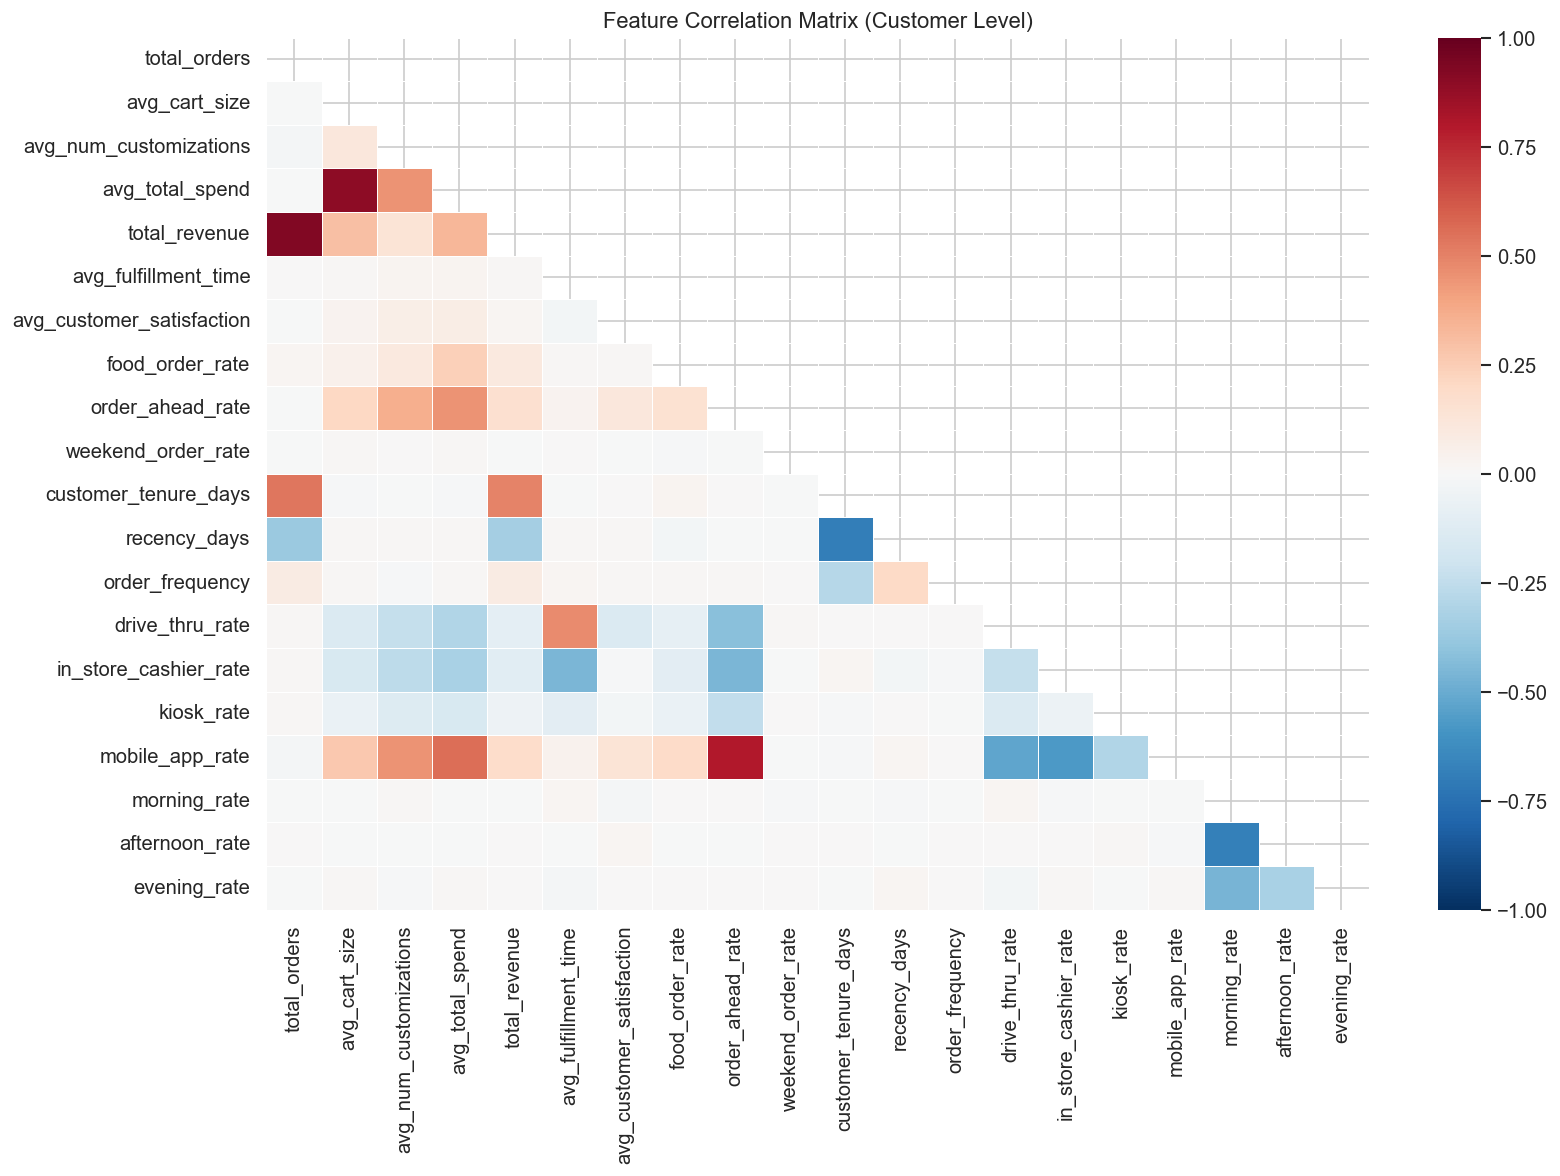

In [69]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(14, 10))
corr = customer_agg[numeric_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix (Customer Level)")
plt.tight_layout()
plt.show()

In [70]:
# Identify highly correlated pairs (|r| > 0.85)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

if high_corr_pairs:
    print("=== Highly Correlated Pairs (|r| > 0.85) ===")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1}  vs  {f2}  :  r = {r}")
else:
    print("No highly correlated feature pairs (ok)")

=== Highly Correlated Pairs (|r| > 0.85) ===
  total_orders  ↔  total_revenue  :  r = 0.928
  avg_cart_size  ↔  avg_total_spend  :  r = 0.891


## Pick the clustering features

In [71]:
# Select clustering features
clustering_features = [
    "total_orders", "recency_days", "order_frequency",
    "avg_total_spend", "total_revenue",
    "avg_cart_size", "avg_num_customizations",
    "food_order_rate", "order_ahead_rate",
    "avg_fulfillment_time", "avg_customer_satisfaction",
    "weekend_order_rate",
]

# Add channel rate columns
channel_rate_cols = [c for c in customer_agg.columns if c.endswith("_rate") and
                     any(ch in c for ch in ["mobile", "drive", "in_store", "kiosk"])]
clustering_features.extend(channel_rate_cols)

# Add time-of-day rate columns
time_rate_cols = [c for c in customer_agg.columns if c.endswith("_rate") and
                  any(t in c for t in ["morning", "afternoon", "evening"])]
clustering_features.extend(time_rate_cols)

# Check if total_revenue is redundant
corr_rev = customer_agg[["total_revenue", "total_orders", "avg_total_spend"]].corr()
print("Revenue correlation check:")
print(corr_rev.round(3).to_string())

if abs(corr_rev.loc["total_revenue", "total_orders"]) > 0.85:
    clustering_features.remove("total_revenue")
    print("\n- Dropped total_revenue (redundant with total_orders)")

print(f"\nFinal clustering features ({len(clustering_features)}):")
for f in clustering_features:
    print(f"  - {f}")

Revenue correlation check:
                 total_revenue  total_orders  avg_total_spend
total_revenue            1.000         0.928            0.334
total_orders             0.928         1.000           -0.006
avg_total_spend          0.334        -0.006            1.000

→ Dropped total_revenue (redundant with total_orders)

Final clustering features (18):
  • total_orders
  • recency_days
  • order_frequency
  • avg_total_spend
  • avg_cart_size
  • avg_num_customizations
  • food_order_rate
  • order_ahead_rate
  • avg_fulfillment_time
  • avg_customer_satisfaction
  • weekend_order_rate
  • drive_thru_rate
  • in_store_cashier_rate
  • kiosk_rate
  • mobile_app_rate
  • morning_rate
  • afternoon_rate
  • evening_rate


In [72]:
# Prepare the feature matrix
X = customer_agg[clustering_features].copy()

# Handle NaNs
print(f"NaN count: {X.isnull().sum().sum()}")
X = X.fillna(0)

# Log-transform highly skewed features
for col in ["total_orders", "order_frequency", "total_revenue", "recency_days"]:
    if col in X.columns:
        skew_val = X[col].skew()
        if abs(skew_val) > 1:
            X[col] = np.log1p(X[col])
            print(f"  Log-transformed {col} (skew was {skew_val:.2f})")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"\nScaled feature matrix: {X_scaled.shape}")
X_scaled.describe().round(2)

NaN count: 0
  Log-transformed order_frequency (skew was 44.49)
  Log-transformed recency_days (skew was 1.76)

Scaled feature matrix: (14988, 18)


,total_orders,recency_days,order_frequency,avg_total_spend,avg_cart_size,avg_num_customizations,food_order_rate,order_ahead_rate,avg_fulfillment_time,avg_customer_satisfaction,weekend_order_rate,drive_thru_rate,in_store_cashier_rate,kiosk_rate,mobile_app_rate,morning_rate,afternoon_rate,evening_rate
count,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00,14988.00
mean,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.22,-3.42,-1.96,-4.47,-3.72,-2.78,-1.58,-1.38,-4.58,-5.32,-1.48,-1.44,-1.13,-0.65,-1.72,-2.29,-1.62,-1.09
25%,-0.65,-0.56,-0.58,-0.67,-0.67,-0.68,-0.74,-0.72,-0.63,-0.62,-0.62,-0.70,-1.13,-0.65,-0.71,-0.74,-0.63,-1.09
50%,-0.26,0.15,-0.12,-0.05,-0.04,-0.06,-0.03,-0.06,-0.02,0.05,-0.07,-0.15,-0.10,-0.65,0.01,0.03,0.03,-0.08
75%,0.52,0.73,0.41,0.61,0.62,0.59,0.57,0.61,0.62,0.62,0.59,0.62,0.58,0.61,0.70,0.61,0.64,0.63
max,4.42,2.02,23.30,5.79,7.13,9.47,3.45,3.26,8.36,2.60,3.69,3.72,4.01,8.12,2.31,2.36,3.35,4.94


## Run K-Means

I will test a few values of k, check the elbow and silhouette results,
and then choose a value that is both reasonable and interpretable.

In [73]:

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=min(5000, len(X_scaled)),
                           random_state=42)
    silhouettes.append(sil)
    print(f"  k={k:2d}  |  inertia={km.inertia_:>12,.0f}  |  silhouette={sil:.4f}")

  k= 2  |  inertia=     235,848  |  silhouette=0.1184
  k= 3  |  inertia=     222,915  |  silhouette=0.0911
  k= 4  |  inertia=     213,840  |  silhouette=0.0612
  k= 5  |  inertia=     207,190  |  silhouette=0.0605
  k= 6  |  inertia=     201,170  |  silhouette=0.0628
  k= 7  |  inertia=     196,189  |  silhouette=0.0620
  k= 8  |  inertia=     191,577  |  silhouette=0.0628
  k= 9  |  inertia=     188,202  |  silhouette=0.0572
  k=10  |  inertia=     184,734  |  silhouette=0.0629


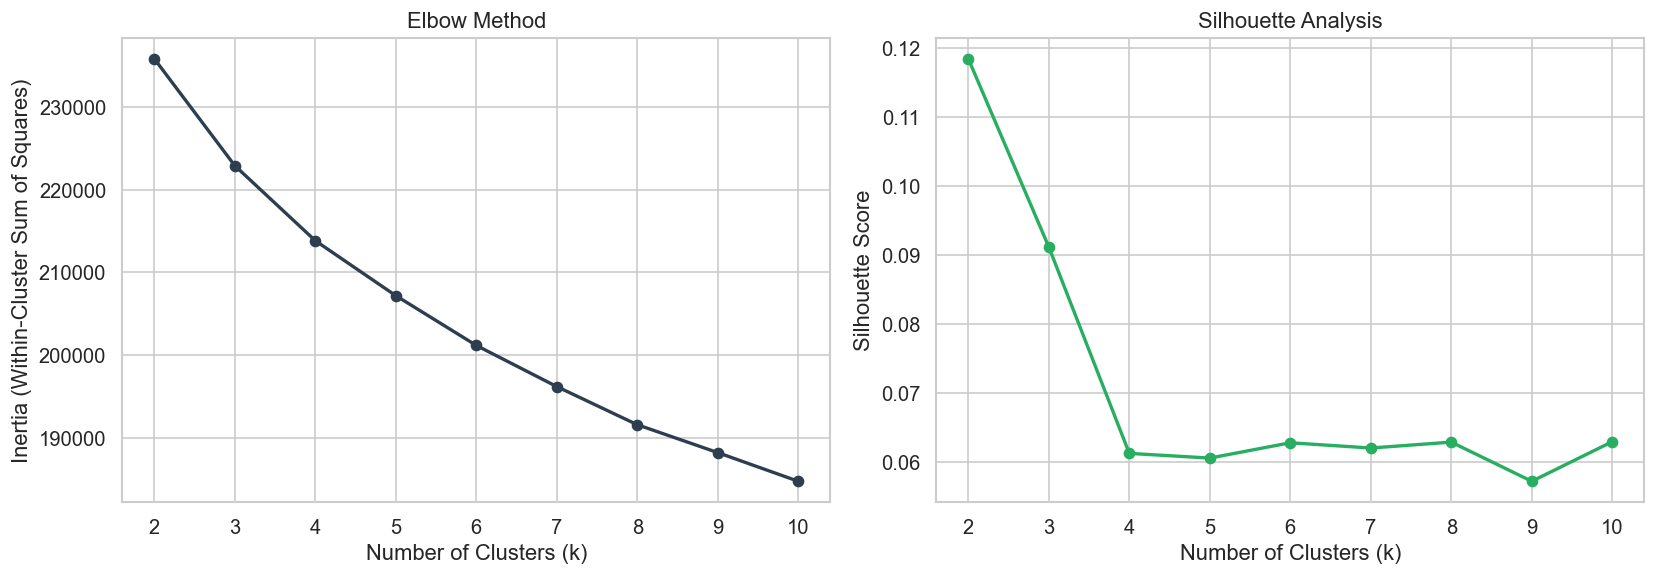


→ Best silhouette score at k = 2  (score = 0.1184)


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, "o-", color="#2c3e50", linewidth=2, markersize=6)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(k_range))

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, "o-", color="#27ae60", linewidth=2, markersize=6)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"\n- Best silhouette score at k = {best_k}  (score = {max(silhouettes):.4f})")

In [75]:
# Fit final model
chosen_k = best_k
print(f"Proceeding with k = {chosen_k}")

final_km = KMeans(n_clusters=chosen_k, n_init=20, random_state=42, max_iter=500)
customer_agg["cluster"] = final_km.fit_predict(X_scaled)

# Cluster sizes
cluster_sizes = customer_agg["cluster"].value_counts().sort_index()
print("\n=== Cluster Sizes ===")
for c, n in cluster_sizes.items():
    print(f"  Cluster {c}: {n:,} customers ({n/len(customer_agg)*100:.1f}%)")

Proceeding with k = 2

=== Cluster Sizes ===
  Cluster 0: 7,309 customers (48.8%)
  Cluster 1: 7,679 customers (51.2%)


## Profile the segments

In [76]:
# Profile each cluster on key features
profile_cols = [
    "total_orders", "avg_total_spend", "total_revenue",
    "avg_cart_size", "avg_num_customizations",
    "food_order_rate", "order_ahead_rate",
    "avg_fulfillment_time", "avg_customer_satisfaction",
    "recency_days", "order_frequency", "weekend_order_rate",
    "is_rewards_member",
]
profile_cols.extend(channel_rate_cols)
profile_cols.extend(time_rate_cols)
profile_cols = [c for c in profile_cols if c in customer_agg.columns]

segment_profile = customer_agg.groupby("cluster")[profile_cols].mean().round(3)
segment_profile.insert(0, "size", cluster_sizes)
segment_profile.insert(1, "pct", (cluster_sizes / len(customer_agg) * 100).round(1))

print("=== Segment Profiles ===")
segment_profile

=== Segment Profiles ===


,size,pct,total_orders,avg_total_spend,total_revenue,avg_cart_size,avg_num_customizations,food_order_rate,order_ahead_rate,avg_fulfillment_time,...,order_frequency,weekend_order_rate,is_rewards_member,drive_thru_rate,in_store_cashier_rate,kiosk_rate,mobile_app_rate,morning_rate,afternoon_rate,evening_rate
cluster,,,,,,,,,,,,,,,,,,,,,
0,7309,48.8,6.678,16.493,109.355,4.056,2.131,0.359,0.445,4.584,...,0.427,0.286,0.490,0.204,0.132,0.047,0.617,0.493,0.324,0.183
1,7679,51.2,6.666,13.329,89.517,3.442,1.517,0.272,0.159,4.510,...,0.425,0.288,0.277,0.351,0.304,0.099,0.246,0.493,0.329,0.179


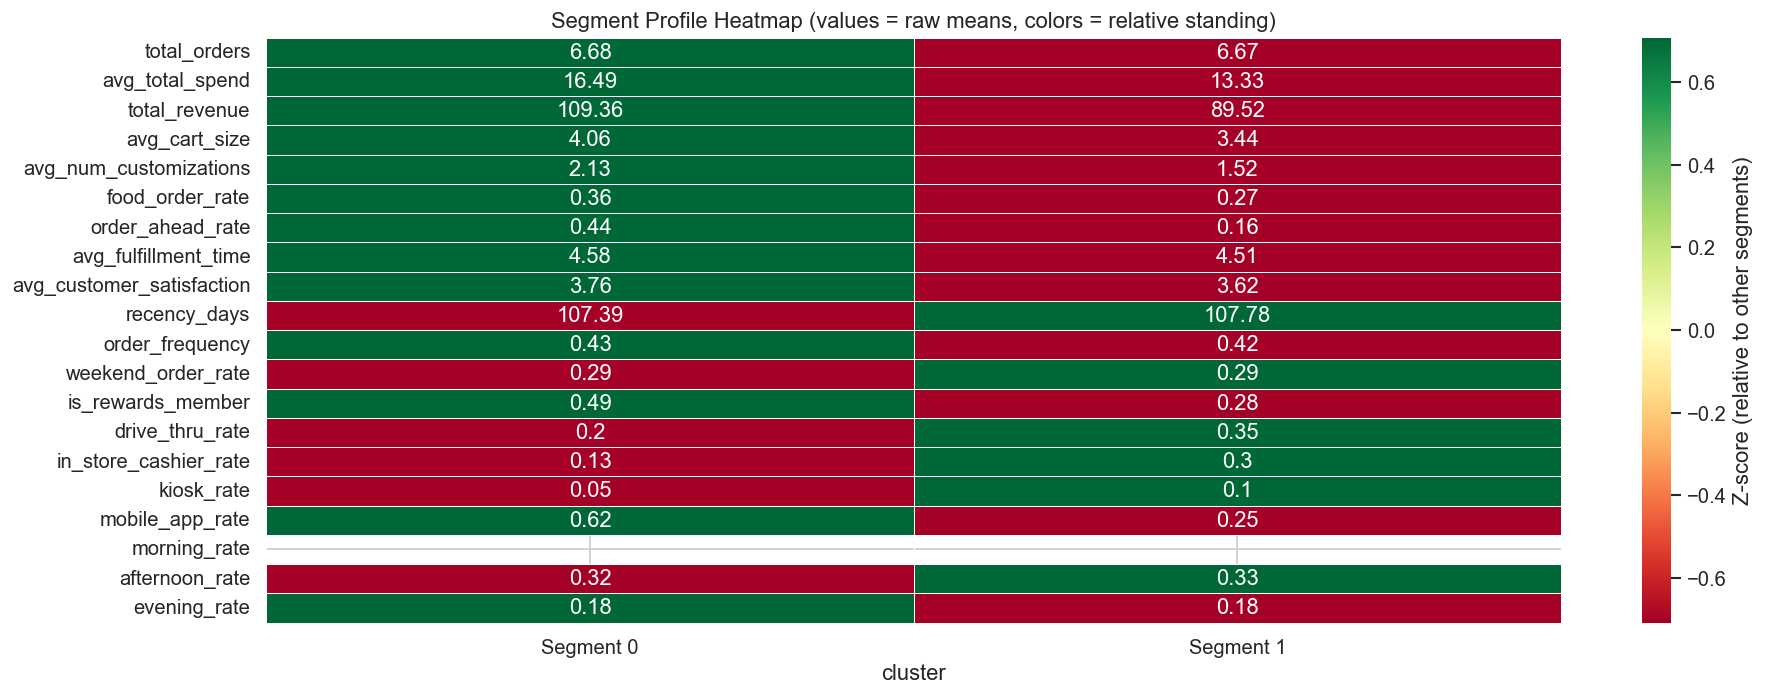

In [77]:
# Heatmap of normalized segment profiles
profile_numeric = segment_profile.drop(columns=["size", "pct"])
profile_z = (profile_numeric - profile_numeric.mean()) / profile_numeric.std()

fig, ax = plt.subplots(figsize=(16, max(6, chosen_k * 1.2)))
sns.heatmap(profile_z.T, annot=profile_numeric.T.round(2), fmt="",
            cmap="RdYlGn", center=0, linewidths=0.5, ax=ax,
            xticklabels=[f"Segment {i}" for i in range(chosen_k)],
            cbar_kws={"label": "Z-score (relative to other segments)"})
ax.set_title("Segment Profile Heatmap (values = raw means, colors = relative standing)")
plt.tight_layout()
plt.show()

In [78]:
# Favorite drink by segment
drink_by_segment = customer_agg.groupby("cluster")["favorite_drink_category"].value_counts(
    normalize=True).round(3)
print("=== Top Drink Preferences by Segment ===")
for seg in range(chosen_k):
    top_drinks = drink_by_segment.loc[seg].head(3)
    print(f"\n  Segment {seg}:")
    for drink, share in top_drinks.items():
        print(f"    {drink:20s}  {share*100:.1f}%")

=== Top Drink Preferences by Segment ===

  Segment 0:
    Brewed Coffee         26.0%
    Espresso              21.6%
    Frappuccino           16.4%

  Segment 1:
    Brewed Coffee         27.6%
    Espresso              20.2%
    Frappuccino           16.6%


In [79]:
# Demographics overlay (for interpretation, not clustering input)
demo_cols = ["customer_age_group", "customer_gender", "region"]
for col in demo_cols:
    if col in data.columns:
        cust_demo = data.groupby("customer_id")[col].agg(lambda x: x.mode().iloc[0])
        customer_agg[col] = customer_agg["customer_id"].map(cust_demo)

print("=== Demographic Mix by Segment ===")
for col in demo_cols:
    if col in customer_agg.columns:
        print(f"\n--- {col} ---")
        ct = pd.crosstab(customer_agg["cluster"], customer_agg[col],
                         normalize="index").round(3) * 100
        print(ct.to_string())

=== Demographic Mix by Segment ===

--- customer_age_group ---
customer_age_group  18-24  25-34  35-44  45-54   55+
cluster                                             
0                    28.8   42.2   17.5   11.0   0.6
1                    12.3   18.3   31.7   18.9  18.8

--- customer_gender ---
customer_gender  Female  Male  Non-binary  Prefer not to say
cluster                                                     
0                  46.0  43.8         5.3                4.9
1                  44.8  45.5         4.8                4.8

--- region ---
region   Midwest  Northeast  Southeast  Southwest  West
cluster                                                
0           28.2       18.8       19.5       15.7  17.7
1           29.7       19.9       19.3       15.2  16.0


## PCA view of the clusters

/Users/raghusmac/Documents/Data_science -projects/starbucks_customer ording patterns/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


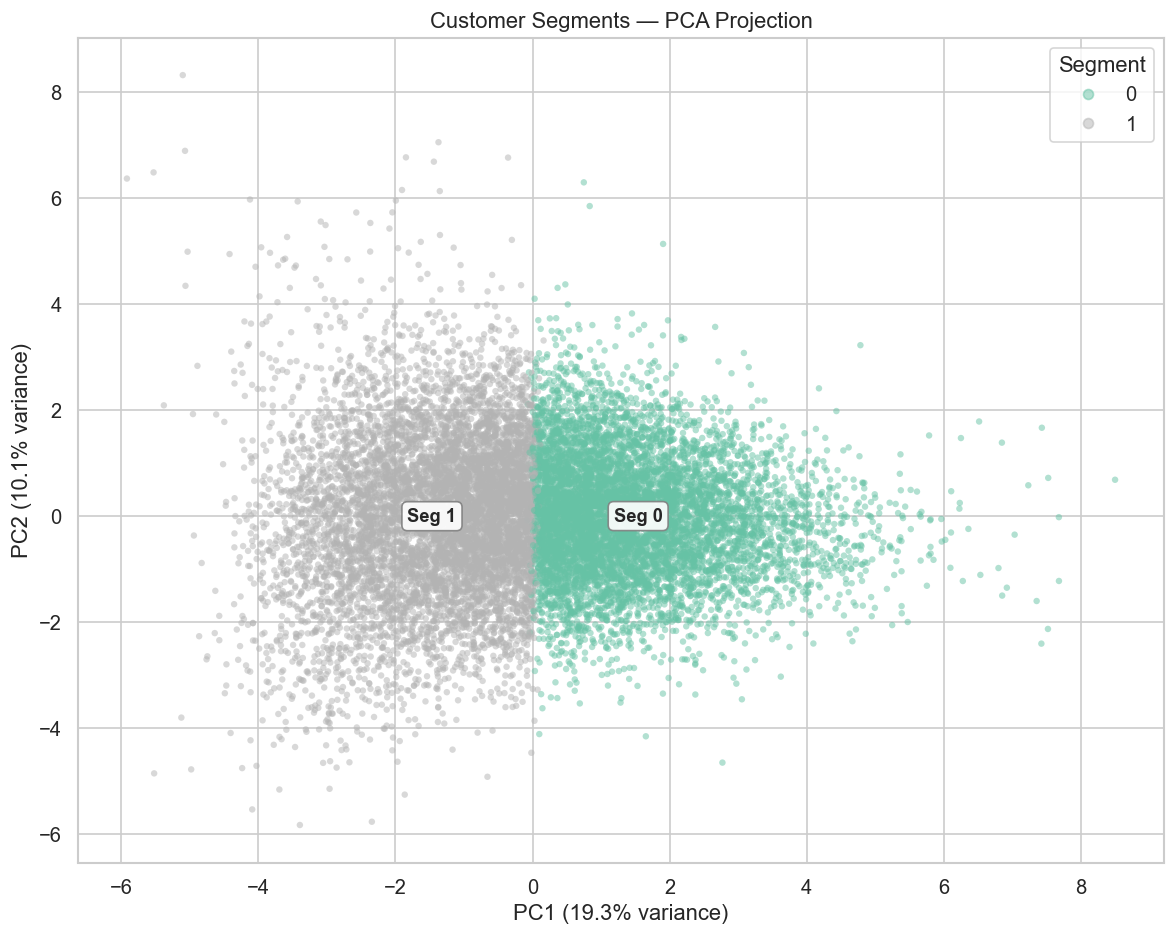

PCA variance explained: 29.5% (2 components)


In [80]:

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(pca_coords[:, 0], pca_coords[:, 1],
                     c=customer_agg["cluster"], cmap="Set2", alpha=0.5, s=15,
                     edgecolors="none")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Customer Segments - PCA Projection")

# Add cluster centers
centers_pca = pca.transform(final_km.cluster_centers_)
for i, (cx, cy) in enumerate(centers_pca):
    ax.annotate(f"Seg {i}", (cx, cy), fontsize=11, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="gray", alpha=0.9))

plt.legend(*scatter.legend_elements(), title="Segment", loc="upper right")
plt.tight_layout()
plt.show()

print(f"PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}% (2 components)")

## Final segment labels and next steps

In [81]:
# Assign final segment names based on the cluster profiles
segment_names = {
    0: "Digital Convenience Customers",
    1: "Store-First Value Customers",
}

for seg in range(chosen_k):
    segment_names.setdefault(seg, f"Segment {seg}")

print("=" * 60)
print("      CUSTOMER SEGMENT SUMMARY")
print("=" * 60)

for seg in range(chosen_k):
    row = segment_profile.loc[seg]
    print(f"\n{'-' * 50}")
    print(f"  Segment {seg}: {segment_names[seg]}")
    print(f"{'-' * 50}")
    print(f"  Size:               {int(row['size']):,} customers ({row['pct']:.1f}%)")
    print(f"  Avg Spend/Order:    ${row['avg_total_spend']:.2f}")
    print(f"  Avg Orders:         {row['total_orders']:.1f}")
    print(f"  Cart Size:          {row['avg_cart_size']:.1f} items")
    print(f"  Customizations:     {row['avg_num_customizations']:.1f}")
    print(f"  Order Ahead Rate:   {row['order_ahead_rate']*100:.1f}%")
    print(f"  Food Order Rate:    {row['food_order_rate']*100:.1f}%")
    print(f"  Satisfaction:       {row['avg_customer_satisfaction']:.2f}/5")
    print(f"  Recency:            {row['recency_days']:.0f} days since last order")


      CUSTOMER SEGMENT SUMMARY

--------------------------------------------------
  Segment 0: Digital Convenience Customers
--------------------------------------------------
  Size:               7,309 customers (48.8%)
  Avg Spend/Order:    $16.49
  Avg Orders:         6.7
  Cart Size:          4.1 items
  Customizations:     2.1
  Order Ahead Rate:   44.5%
  Food Order Rate:    35.9%
  Satisfaction:       3.76/5
  Recency:            107 days since last order

--------------------------------------------------
  Segment 1: Store-First Value Customers
--------------------------------------------------
  Size:               7,679 customers (51.2%)
  Avg Spend/Order:    $13.33
  Avg Orders:         6.7
  Cart Size:          3.4 items
  Customizations:     1.5
  Order Ahead Rate:   15.9%
  Food Order Rate:    27.2%
  Satisfaction:       3.62/5
  Recency:            108 days since last order


In [82]:
# Practical next steps by segment
segment_actions = {
    0: [
        "Keep app ordering and pickup reliable, because this group already leans heavily on digital convenience.",
        "Test food pairings and add-on offers, since cart size and customization are already strong here.",
        "Use rewards and mobile campaigns first for this segment, because the behavior already supports it.",
    ],
    1: [
        "Focus on value bundles and rewards enrollment, since spend and rewards participation are lower in this group.",
        "Try light nudges toward order-ahead or app usage instead of assuming a full shift to digital.",
        "Review drive-thru and in-store experience, because satisfaction is slightly lower here.",
    ],
}

print("\n" + "=" * 60)
print("      SUGGESTED NEXT STEPS")
print("=" * 60)

for seg in range(chosen_k):
    print(f"\nSegment {seg} - {segment_names[seg]}")
    for action in segment_actions.get(seg, ["No action notes added yet."]):
        print(f"  - {action}")



      SUGGESTED NEXT STEPS

Segment 0 - Digital Convenience Customers
  - Keep app ordering and pickup reliable, because this group already leans heavily on digital convenience.
  - Test food pairings and add-on offers, since cart size and customization are already strong here.
  - Use rewards and mobile campaigns first for this segment, because the behavior already supports it.

Segment 1 - Store-First Value Customers
  - Focus on value bundles and rewards enrollment, since spend and rewards participation are lower in this group.
  - Try light nudges toward order-ahead or app usage instead of assuming a full shift to digital.
  - Review drive-thru and in-store experience, because satisfaction is slightly lower here.


## Final summary table

In [83]:
# Clean summary table for stakeholders
summary_table = pd.DataFrame({
    "Segment": [segment_names[i] for i in range(chosen_k)],
    "Customers": [int(segment_profile.loc[i, "size"]) for i in range(chosen_k)],
    "% of Total": [segment_profile.loc[i, "pct"] for i in range(chosen_k)],
    "Avg Spend": [f"${segment_profile.loc[i, 'avg_total_spend']:.2f}" for i in range(chosen_k)],
    "Avg Orders": [round(segment_profile.loc[i, "total_orders"], 1) for i in range(chosen_k)],
    "Satisfaction": [round(segment_profile.loc[i, "avg_customer_satisfaction"], 2) for i in range(chosen_k)],
    "Order Ahead %": [f"{segment_profile.loc[i, 'order_ahead_rate']*100:.1f}%" for i in range(chosen_k)],
    "Food %": [f"{segment_profile.loc[i, 'food_order_rate']*100:.1f}%" for i in range(chosen_k)],
})
summary_table

                           Segment  Customers  % of Total Avg Spend  \
0  Digital Convenience Customers       7309        48.8    $16.49   
1   Store-First Value Customers       7679        51.2    $13.33   

   Avg Orders  Satisfaction Order Ahead % Food %  
0         6.7          3.76         44.5%  35.9%  
1         6.7          3.62         15.9%  27.2%  

In [84]:
# Save customer-level data with segment assignments
output_path = "customer_segments_output.csv"
customer_agg["segment_name"] = customer_agg["cluster"].map(segment_names)
customer_agg.to_csv(output_path, index=False)
print(f"\nCustomer segments saved to: {output_path}")
print(f"   {customer_agg.shape[0]:,} customers × {customer_agg.shape[1]} features")


✅ Customer segments saved to: customer_segments_output.csv
   14,988 customers × 28 features


---
At this point, the workflow is complete: the data was checked, customer features were built,
clusters were created, and the segments were summarized in business terms.